In [16]:
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, rosen, rosen_der
import numpy as np


In [8]:
df = pd.read_table('data/all_cities_2021_2025.csv', sep=',')

In [9]:
df

,city,n_trains,tx,day,mean_delay,fraction_cancelled,fraction_delayed,weekday,year
0,Berlin_Hbf,499,15.320000,2022-05-01,222.208589,0.020040,0.967280,6,2022
1,Berlin_Hbf,476,19.080000,2022-05-02,245.744681,0.012605,0.972340,0,2022
2,Berlin_Hbf,475,18.539999,2022-05-03,264.690832,0.012632,0.970149,1,2022
3,Berlin_Hbf,492,19.350000,2022-05-04,251.949686,0.030488,0.983229,2,2022
4,Berlin_Hbf,496,18.440000,2022-05-05,310.234542,0.054435,0.974414,3,2022
...,...,...,...,...,...,...,...,...,...
6095,Stuttgart_Hbf,741,14.929999,2025-09-27,0.000000,0.000000,1.000000,5,2025
6096,Stuttgart_Hbf,782,14.679999,2025-09-28,240.939948,0.020460,0.985640,6,2025
6097,Stuttgart_Hbf,7379,17.520000,2025-09-29,587.916325,0.008809,0.975390,0,2025
6098,Stuttgart_Hbf,7517,16.560000,2025-09-30,460.646204,0.011840,0.969575,1,2025


In [99]:
df = df.dropna()

## proof of concept:

In [116]:
def error(parameters):
    y = df.mean_delay.values
    y_hat = estimated_delay(parameters).values
    sigma = np.std(y - y_hat, ddof=1)
    nll = 0.5 * ((y - y_hat)**2) / sigma**2 + np.log(sigma) + 0.5*np.log(2*np.pi)
    return nll.mean()

def estimated_delay(parameters):
    b1_t = parameters[0]
    #b2_t = parameters[2]
    mu_cities = parameters[-10:]

    y = b1_t * df.tx
    for city,mu_city in zip(city_names, mu_cities):
        y += (df.city == city) * mu_city
    return y

city_names = np.unique(df.city)
popt = scipy.optimize.minimize(error, x0=[1] + [1]*10)#, method='Powell')
popt.x

array([  6.19257969, 251.5869963 , 314.59513576, 270.41340922,
       283.07055068, 311.25921986, 399.47608061, 285.78108457,
       273.15758259, 386.64334955, 228.6846648 ])

In [114]:
city_names

array(['Berlin_Hbf', 'Dortmund_Hbf', 'Düsseldorf_Hbf', 'Essen_Hbf',
       'Frankfurt_Main_Hbf', 'Hamburg_Hbf', 'Hannover_Hbf', 'Köln_Hbf',
       'München_Hbf', 'Stuttgart_Hbf'], dtype=object)

In [131]:
def error(parameters):
    y = df.mean_delay.values
    y_hat = estimated_delay(parameters).values
    sigma = np.std(y - y_hat, ddof=1)
    nll = 0.5 * ((y - y_hat)**2) / sigma**2 + np.log(sigma) + 0.5*np.log(2*np.pi)
    return nll.mean()

In [109]:
def estimated_delay(parameters):
    threshold_t = parameters[0]
    b1_t = parameters[1]
    #b2_t = parameters[2]
    mu_cities = parameters[-10:]

    y = (df.tx > threshold_t) * b1_t * df.tx
    for city,mu_city in zip(city_names, mu_cities):
        y += (df.city == city) * mu_city
    return y

city_names = np.unique(df.city)
popt = scipy.optimize.minimize(error, x0=[36, 1] + [1]*10, method='Powell')
popt.x

array([ 45.56955394,   8.76378688, 399.47528084, 457.23221546,
       416.08615025, 421.95248017, 462.37691664, 535.48084155,
       428.91150612, 420.58914078, 529.70352321, 378.17146512])

In [129]:
def estimated_delay(parameters):
    threshold_t = parameters[0]
    b1_t = parameters[1]
    #b2_t = parameters[2]
    mu_cities = parameters[-17:-7]
    mu_dows = parameters[-7:]

    y = (df.tx > threshold_t) * b1_t * df.tx
    for city,mu_city in zip(city_names, mu_cities):
        y += (df.city == city) * mu_city
    for dow,mu_dow in zip(range(7), mu_dows):
        y += (df.weekday == dow) * mu_dow
    return y

city_names = np.unique(df.city)
popt = scipy.optimize.minimize(error, x0=[25, 6] + [150]*10 + [200]*7, method='Nelder-Mead')
popt.x

array([ 10.47000292,   5.1122622 , 127.72588858, 192.77114042,
       145.37498607, 134.38590505, 185.90366255, 263.27457889,
       152.74962813, 135.7204971 , 261.31673688, 102.32468821,
       140.85606349, 167.62670374, 160.1766984 , 169.75490365,
       188.17808593, 126.6872511 , 150.6340983 ])

In [138]:
def estimated_delay(parameters):
    threshold_t = parameters[0]
    b1_t = parameters[1]
    b2_t = parameters[2]
    mu_cities = parameters[-17:-7]
    mu_dows = parameters[-7:]

    y = (df.tx <= threshold_t) * b1_t * df.tx
    y += (df.tx > threshold_t) * b2_t * df.tx
    
    for city,mu_city in zip(city_names, mu_cities):
        y += (df.city == city) * mu_city
    for dow,mu_dow in zip(range(7), mu_dows):
        y += (df.weekday == dow) * mu_dow
    return y

city_names = np.unique(df.city)
x0 = [25, 6, 6] + [150]*10 + [200]*7
popt = scipy.optimize.minimize(error, x0=x0, method='Nelder-Mead')
popt.x

array([ 34.31999884,   3.65785206,   8.53420797,  86.07242316,
       142.45675033, 103.41091687, 109.89458586, 139.60440943,
       230.99757507, 112.01239744,  96.45011364, 213.52599436,
        60.65006871, 212.62391186, 236.41736106, 231.20457919,
       243.87912681, 264.26591269, 197.45484389, 218.72373666])

In [140]:
np.corrcoef(df.mean_delay, estimated_delay(popt.x))

array([[1.        , 0.27531819],
       [0.27531819, 1.        ]])

In [144]:
from sklearn.metrics import r2_score

coefficient_of_dermination = r2_score(df.mean_delay, estimated_delay(popt.x))
coefficient_of_dermination

0.07567043727599443

Text(0, 0.5, 'prediction')

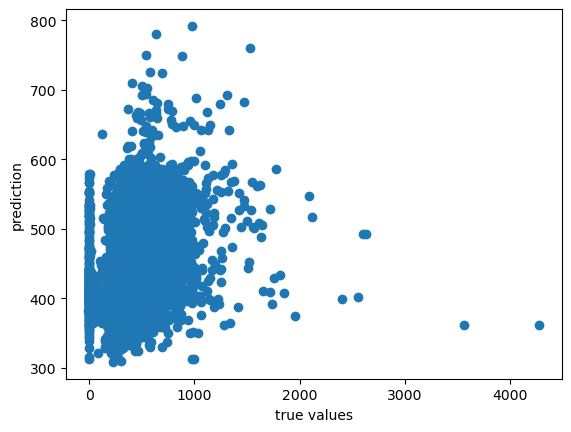

In [139]:
fig, ax = plt.subplots()
ax.scatter(df.mean_delay, estimated_delay(popt.x))
ax.set_xlabel('true values')
ax.set_ylabel('prediction')